## 1. Data 

In [30]:
import pandas as pd

In [31]:
file_path = "listings_newyork.xlsx"
listing = pd.read_excel(file_path)

In [32]:
import pandas as pd

In [33]:
listing.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,40824219,https://www.airbnb.com/rooms/40824219,20251001171547,2025-10-02,city scrape,Room close to Manhattan for FEMALE guests,This cozy spacious room includes a twin size b...,Sunnyside is a safe residental area. <br />The...,https://a0.muscache.com/pictures/hosting/Hosti...,317540555,...,4.88,4.94,4.69,NaN,f,3,0,3,0,0.23
1,40833186,https://www.airbnb.com/rooms/40833186,20251001171547,2025-10-02,previous scrape,Soho LES East village private room downtown,NaN,NaN,https://a0.muscache.com/pictures/1f093bbc-936c...,68718914,...,NaN,NaN,NaN,NaN,t,1,0,1,0,NaN
2,40837137,https://www.airbnb.com/rooms/40837137,20251001171547,2025-10-02,previous scrape,Sunset Park - Quiet and close to subway!,"Cozy, lovely bedroom with a comfortable full s...",the sunset park of Brooklyn,https://a0.muscache.com/pictures/01c4e91e-4012...,317770098,...,5.00,5.00,5.00,NaN,f,1,0,1,0,0.01
3,40838018,https://www.airbnb.com/rooms/40838018,20251001171547,2025-10-02,previous scrape,Cozy One Bedroom in Clinton Hill,This sunny one-bedroom apartment is located in...,Clinton Hill is one of the best neighborhoods ...,https://a0.muscache.com/pictures/9322d54a-6eb7...,17211451,...,5.00,5.00,5.00,NaN,t,1,1,0,0,0.01
4,40839416,https://www.airbnb.com/rooms/40839416,20251001171547,2025-10-02,city scrape,ðŸª´XL dojo ðŸŒ¾ shared green yogi palace apt ...,"New York City living at its best. A massive, c...",Live like the Ramones > The East Village is st...,https://a0.muscache.com/pictures/hosting/Hosti...,4765305,...,5.00,5.00,4.95,NaN,f,8,0,8,0,0.40


## *Observation

In [34]:
newyork = listing.copy()

In [35]:
newyork.shape #36111 observations, 79 columns

(36111, 79)

In [36]:
newyork.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [37]:
#Check outliers and correlation of numerical values only

In [38]:
# Select numeric columns only
numeric_cols = newyork.select_dtypes(include=['float64', 'int64']).columns

In [39]:
from matplotlib import pyplot as plt

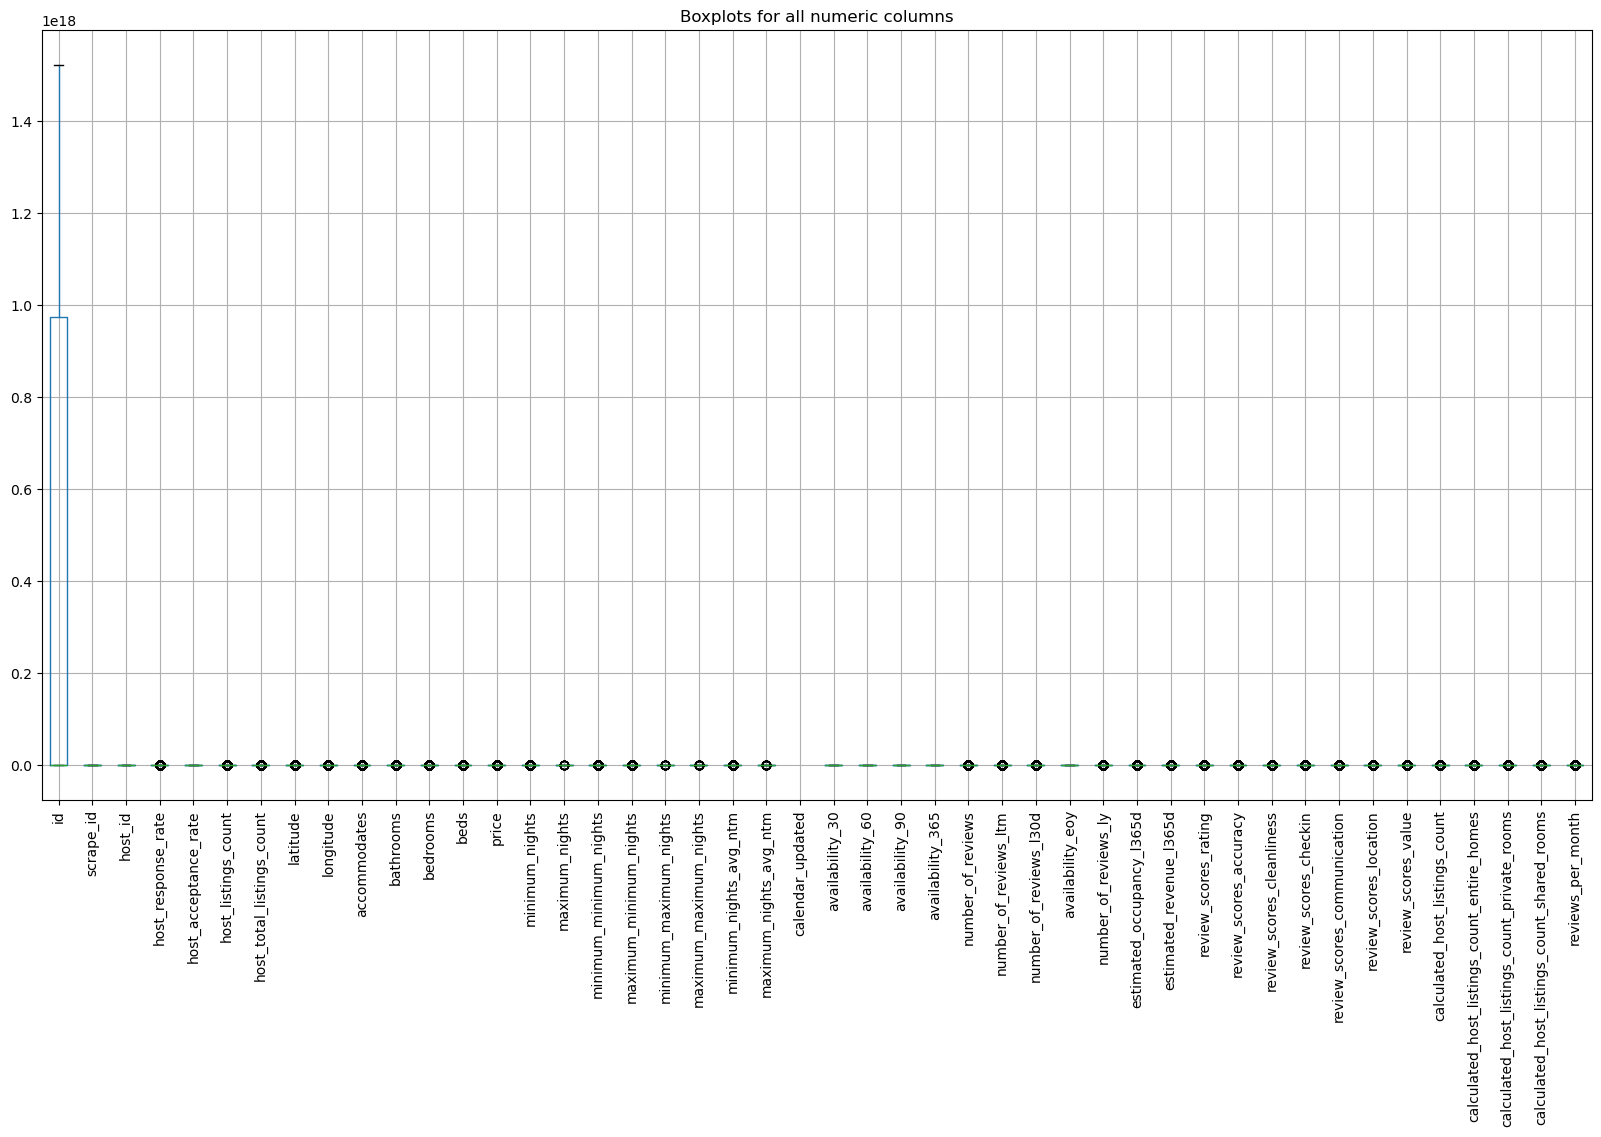

In [40]:
newyork[numeric_cols].boxplot(figsize=(20,10), rot=90)
plt.title('Boxplots for all numeric columns')
plt.show()

In [41]:
import seaborn as sns

In [42]:
sub = newyork[numeric_cols].copy()
sub = sub.drop(columns=['calendar_updated', 'scrape_id'], errors='ignore')

In [43]:
corr1 = sub.corr()
corr1

,id,host_id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
id,1.000000,0.499500,0.071690,0.032316,0.192507,0.203039,0.001592,0.014246,0.044791,0.038329,...,0.004847,-0.062544,-0.083379,-0.068102,-0.118760,0.205470,0.177630,0.088776,0.082792,0.202290
host_id,0.499500,1.000000,0.054254,0.133635,0.170723,0.158298,0.000460,0.092746,0.072474,-0.026153,...,-0.022863,-0.101850,-0.121354,-0.088348,-0.133348,-0.063667,-0.051882,-0.055763,0.050678,0.243275
host_response_rate,0.071690,0.054254,1.000000,0.428665,0.089575,0.103526,0.012475,0.027306,-0.008326,-0.005577,...,0.044157,0.026509,0.046855,-0.010822,0.011182,0.101696,0.010898,0.102055,0.010133,0.103954
host_acceptance_rate,0.032316,0.133635,0.428665,1.000000,-0.143196,-0.127498,0.018008,0.040701,0.111134,-0.023704,...,0.069308,0.020948,0.036850,-0.011528,0.017149,-0.296172,-0.086951,-0.288834,0.039907,0.209836
host_listings_count,0.192507,0.170723,0.089575,-0.143196,1.000000,0.929975,0.055982,-0.092711,-0.013934,-0.024217,...,-0.075550,-0.090489,-0.130012,-0.049613,-0.147989,0.469939,0.633040,0.124754,-0.009572,-0.035819
host_total_listings_count,0.203039,0.158298,0.103526,-0.127498,0.929975,1.000000,0.055849,-0.097694,0.005167,-0.006172,...,-0.066875,-0.093578,-0.123067,-0.050332,-0.139422,0.515538,0.527941,0.215780,-0.012190,-0.021011
latitude,0.001592,0.000460,0.012475,0.018008,0.055982,0.055849,1.000000,0.041180,-0.015962,-0.038254,...,-0.053800,-0.042635,-0.049693,0.014717,-0.062095,0.060417,0.074946,-0.033751,-0.013309,-0.042282
longitude,0.014246,0.092746,0.027306,0.040701,-0.092711,-0.097694,0.041180,1.000000,-0.021688,0.002667,...,0.022857,0.012165,0.013970,-0.137439,0.031659,-0.117571,-0.148053,0.067635,0.018557,0.023880
accommodates,0.044791,0.072474,-0.008326,0.111134,-0.013934,0.005167,-0.015962,-0.021688,1.000000,0.386206,...,0.032500,-0.006534,0.011390,-0.001858,-0.008065,-0.058595,-0.002129,-0.162549,-0.053537,0.034898
bathrooms,0.038329,-0.026153,-0.005577,-0.023704,-0.024217,-0.006172,-0.038254,0.002667,0.386206,1.000000,...,0.013949,0.007095,0.012800,-0.002022,0.021276,0.018619,-0.010526,0.083205,0.077051,-0.039762


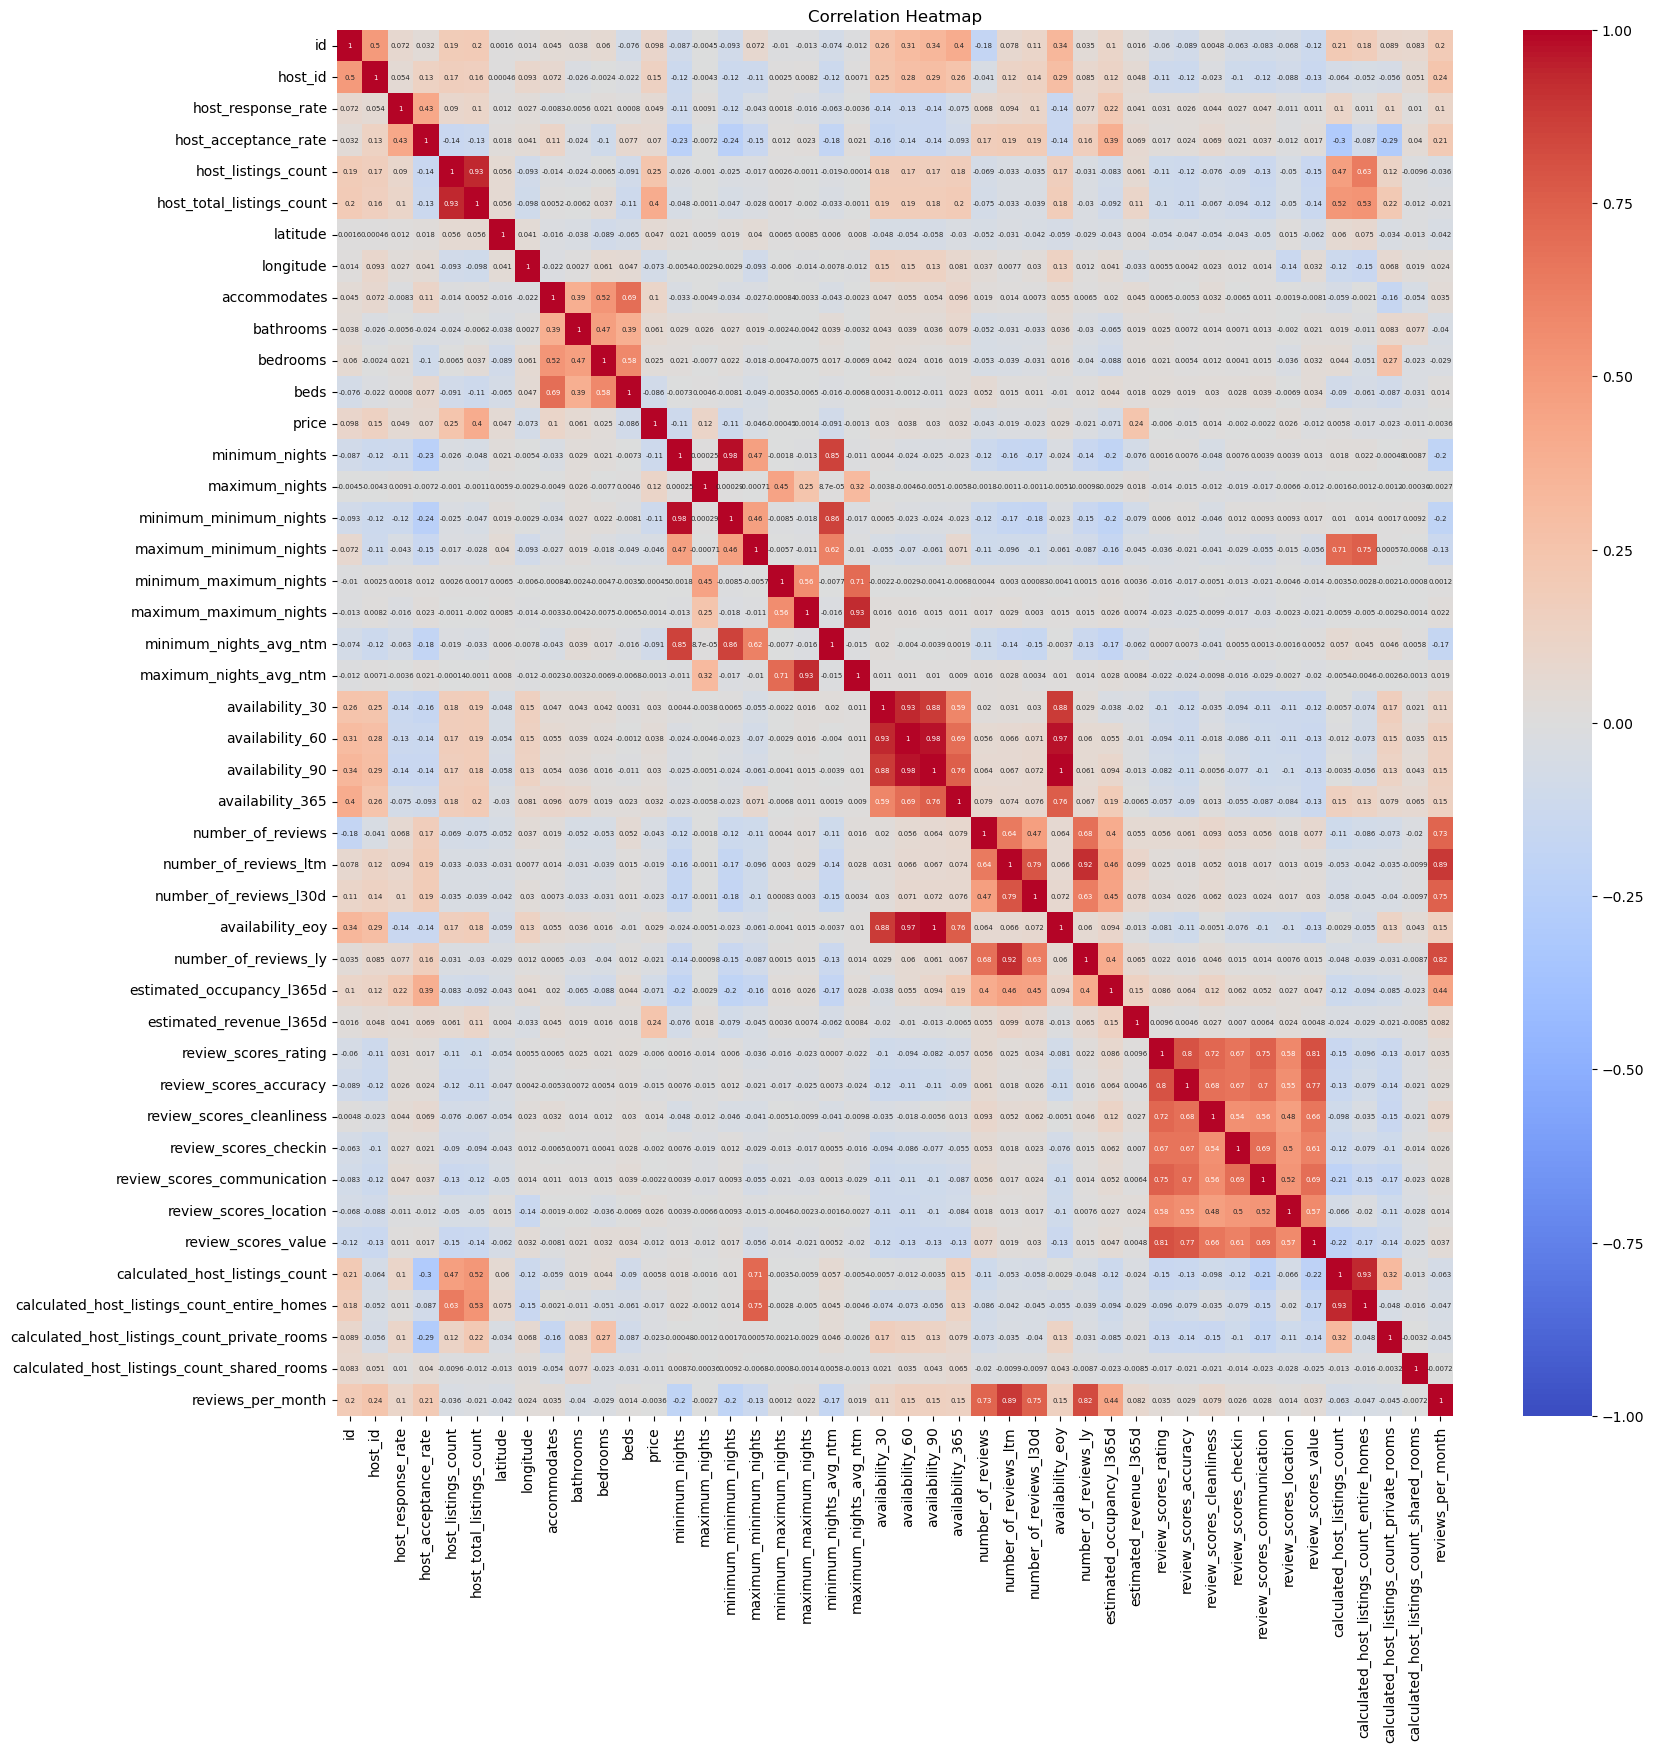

In [44]:
plt.figure(figsize=(18,18))
sns.heatmap(corr1, vmin=-1, vmax=1, center=0, annot=True, cmap="coolwarm", annot_kws={"fontsize":5})
plt.title("Correlation Heatmap")
plt.show()

## 2. Data cleansing

## *Column dropping decision

In [45]:
#minimum nights and maximum nights: keep the main one only

In [46]:
#availability: Keep only _30 and _365 as the mimimum values and maximum value for the range of availability

In [47]:
#number of reviews, review scores rating, calculated host listings counts: keep the main one only

In [48]:
#reviews_per_month: drop as it highly correlated to number_of_reviews

In [49]:
#as property type and room type show overlapping values >> drop the former one as it contains too many texts, we will just focus on the general listing types only

In [50]:
newyork["property_type"].value_counts()

property_type
Entire rental unit             15253
Private room in rental unit     9852
Private room in home            2629
Room in hotel                   1426
Entire home                     1247
                               ...  
Private room in in-law             1
Private room in tent               1
Entire bed and breakfast           1
Cave                               1
Dome                               1
Name: count, Length: 74, dtype: int64

In [51]:
newyork["room_type"].value_counts()

room_type
Entire home/apt    19167
Private room       16350
Hotel room           351
Shared room          243
Name: count, dtype: int64

==> Consider keeping only room_type, as property_type contains text, and it is redundant to room_type

In [52]:
listing["host_listings_count"].isnull().sum()

np.int64(1167)

In [53]:
listing["calculated_host_listings_count"].isnull().sum()

np.int64(0)

### ***Decision: May consider dropping:
- Pure identifiers / URLs
- Descriptive text / unstructured info
- Time-related
- Metadata (rarely useful in cross-section)
- Duplicative / overly detailed geographic or host info
- Columns that are aggregations of others (redundant)



In [54]:
newyork.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [55]:
newyork.drop(columns=['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 
                      'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about',  'host_response_time', 'host_thumbnail_url', 
                      'host_picture_url', 'host_neighbourhood', 'host_listings_count','host_verifications', 'host_has_profile_pic', 
                      'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'latitude', 'longitude', 
                      'property_type', 'bathrooms_text', 'amenities', 'minimum_minimum_nights', 'maximum_minimum_nights', 
                       'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated',
                      'availability_60', 'availability_90', 'calendar_last_scraped', 'number_of_reviews_ltm', 
                       'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d','estimated_revenue_l365d', 
                       'first_review', 'last_review', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin',
                       'review_scores_communication', 'review_scores_location', 'review_scores_value', 'license', 
                      'calculated_host_listings_count_entire_homes',
                       'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 
                      'reviews_per_month'], inplace=True)   

In [56]:
newyork.shape 
#same number of obs, yet the #cols was reduced to 20

(36111, 20)

In [57]:
newyork.columns #after cleansing

Index(['host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_total_listings_count', 'neighbourhood_group_cleansed',
       'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price',
       'minimum_nights', 'maximum_nights', 'has_availability',
       'availability_30', 'availability_365', 'number_of_reviews',
       'review_scores_rating', 'instant_bookable',
       'calculated_host_listings_count'],
      dtype='object')

In [58]:
newyork.isnull().values.any()

np.True_

In [59]:
newyork.isnull().sum()

host_response_rate                15774
host_acceptance_rate              15595
host_is_superhost                   384
host_total_listings_count          1167
neighbourhood_group_cleansed          0
room_type                             0
accommodates                          0
bathrooms                         14411
bedrooms                           5949
beds                              14468
price                             14783
minimum_nights                        0
maximum_nights                        0
has_availability                   5665
availability_30                       0
availability_365                      0
number_of_reviews                     0
review_scores_rating              11188
instant_bookable                      0
calculated_host_listings_count        0
dtype: int64

In [60]:
newyork["has_availability"].value_counts()

has_availability
t    30446
Name: count, dtype: int64

*has_availability used to indicate if a listing is active and available for booking. It's often used in data analysis, where t (true) means the listing is active and f (false) means it is not ==> drop obs that are not available on Airbnb

In [61]:
newyork.dropna(subset=['has_availability'], inplace=True)

In [62]:
newyork.isnull().sum() #after dropping NA in has_availability

host_response_rate                10261
host_acceptance_rate              10104
host_is_superhost                   372
host_total_listings_count          1160
neighbourhood_group_cleansed          0
room_type                             0
accommodates                          0
bathrooms                          9000
bedrooms                           3801
beds                               9057
price                              9372
minimum_nights                        0
maximum_nights                        0
has_availability                      0
availability_30                       0
availability_365                      0
number_of_reviews                     0
review_scores_rating               8346
instant_bookable                      0
calculated_host_listings_count        0
dtype: int64

In [63]:
newyork.shape

(30446, 20)

### *Dependent variable: Price

In [64]:
newyork["price"].describe() #original 'price' data

count    21074.000000
mean       686.502800
std       4507.003427
min         10.000000
25%         89.000000
50%        154.000000
75%        280.000000
max      50104.000000
Name: price, dtype: float64

==> It is shown that the distribution of price is right-skewed with the median < mean. Also, it was observed that the 'price' variable contains extreme outliers, as the max is 50,104, while the 75th percentile is only 279. That’s >170× larger than typical prices

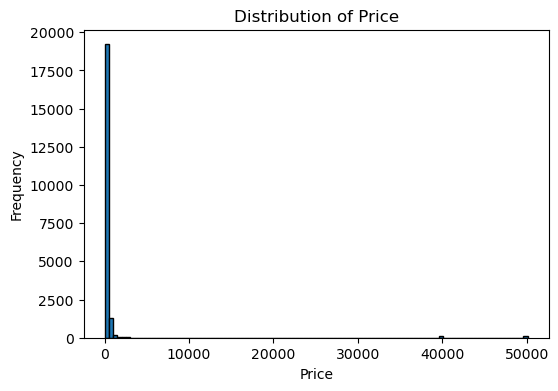

In [65]:
plt.figure(figsize=(6,4))
plt.hist(newyork["price"], bins=100, edgecolor='black')
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [66]:
numeric_cols2 = newyork.select_dtypes(include=['float64', 'int64']).columns

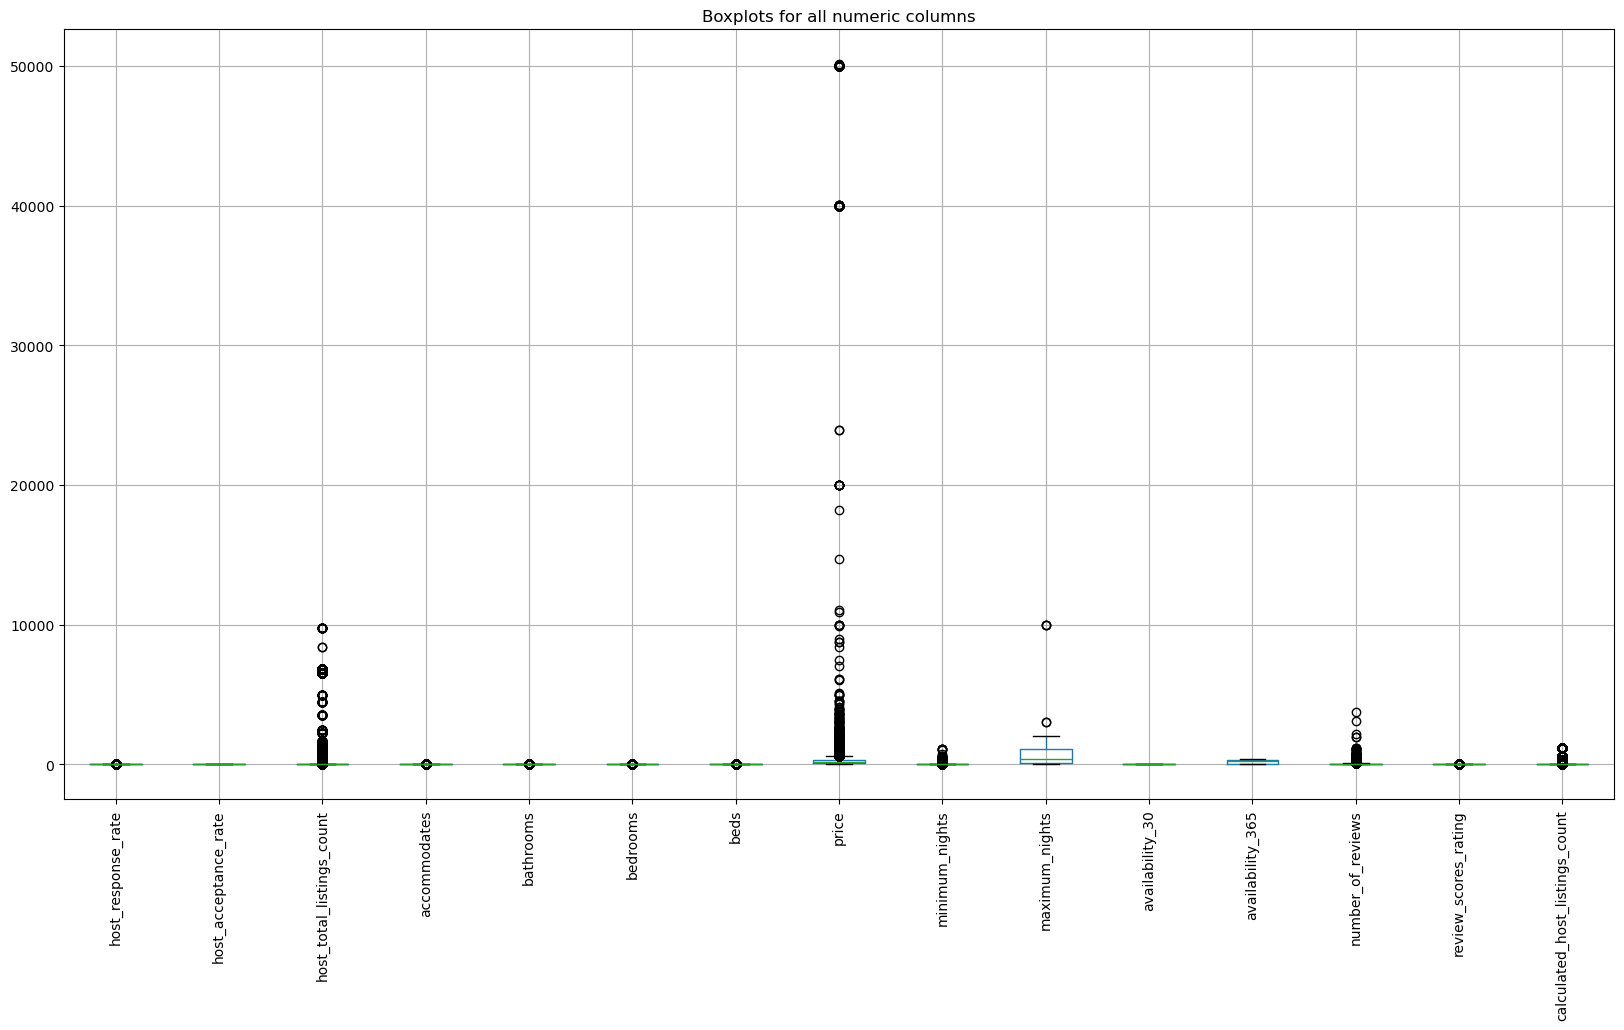

In [67]:
newyork[numeric_cols2].boxplot(figsize=(20,10), rot=90)
plt.title('Boxplots for all numeric columns')
plt.show()

In [68]:
import numpy as np

In [69]:
newyork["log_price"] = np.log(newyork["price"]+1)

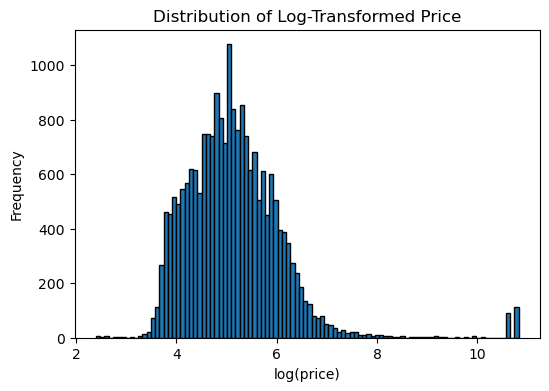

In [70]:
plt.figure(figsize=(6,4))
plt.hist(newyork["log_price"], bins=100, edgecolor='black')
plt.title("Distribution of Log-Transformed Price")
plt.xlabel("log(price)")
plt.ylabel("Frequency")
plt.show()

==> Observation:
- The distribution of log_price is approximately normal (bell-shaped), which is more suitable for linear regression.

- The original price variable had extreme right skewness and many outliers, but the log transformation has reduced skewness and stabilized variance.

- A few high values remain, but they are not extreme anymore and do not require removal at this stage.

- Outliers will not be removed since they may represent real high-value Airbnb listings.

- Missing values in price (and therefore log_price) will be dropped before regression, because regression cannot handle missing target values.

In [71]:
#Removing missing values in price

In [72]:
newyork.dropna(subset=['price'], inplace=True)

In [73]:
newyork["price"].isnull().values.any()

np.False_

In [74]:
newyork["price"].describe() 

count    21074.000000
mean       686.502800
std       4507.003427
min         10.000000
25%         89.000000
50%        154.000000
75%        280.000000
max      50104.000000
Name: price, dtype: float64

### *Independent variables

In [75]:
newyork.isnull().sum() #after dropping missing values in price

host_response_rate                3975
host_acceptance_rate              4145
host_is_superhost                  308
host_total_listings_count         1042
neighbourhood_group_cleansed         0
room_type                            0
accommodates                         0
bathrooms                            7
bedrooms                            85
beds                                41
price                                0
minimum_nights                       0
maximum_nights                       0
has_availability                     0
availability_30                      0
availability_365                     0
number_of_reviews                    0
review_scores_rating              6141
instant_bookable                     0
calculated_host_listings_count       0
log_price                            0
dtype: int64

In [76]:
#host_response_rate >> mean substitution

In [77]:
newyork["host_response_rate"].describe()

count    17099.000000
mean         0.891377
std          0.246290
min          0.000000
25%          0.930000
50%          1.000000
75%          1.000000
max          1.000000
Name: host_response_rate, dtype: float64

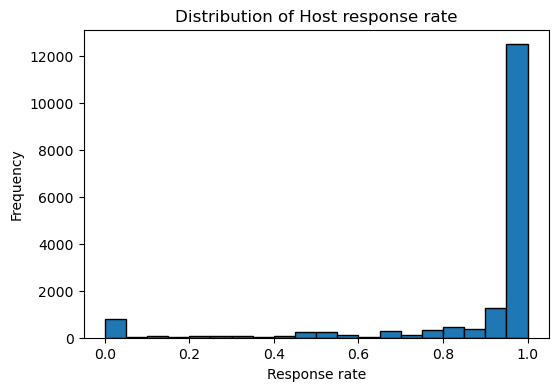

In [78]:
plt.figure(figsize=(6,4))
plt.hist(newyork["host_response_rate"], bins=20, edgecolor='black')
plt.title("Distribution of Host response rate")
plt.xlabel("Response rate")
plt.ylabel("Frequency")
plt.show()

In [79]:
response_rate_mean = newyork["host_response_rate"].mean()
response_rate_mean

np.float64(0.8913766886952454)

In [80]:
newyork.fillna({"host_response_rate": response_rate_mean}, inplace = True)

In [81]:
#host_acceptance_rate >> mean substitution

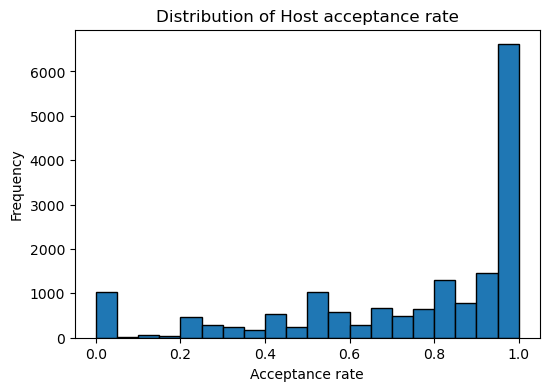

In [82]:
plt.figure(figsize=(6,4))
plt.hist(newyork["host_acceptance_rate"], bins=20, edgecolor='black')
plt.title("Distribution of Host acceptance rate")
plt.xlabel("Acceptance rate")
plt.ylabel("Frequency")
plt.show()

In [83]:
acceptance_rate_mean = newyork["host_acceptance_rate"].mean()
acceptance_rate_mean

np.float64(0.7494536003307933)

In [84]:
newyork.fillna({"host_acceptance_rate": acceptance_rate_mean}, inplace = True)

In [85]:
newyork.isnull().sum()

host_response_rate                   0
host_acceptance_rate                 0
host_is_superhost                  308
host_total_listings_count         1042
neighbourhood_group_cleansed         0
room_type                            0
accommodates                         0
bathrooms                            7
bedrooms                            85
beds                                41
price                                0
minimum_nights                       0
maximum_nights                       0
has_availability                     0
availability_30                      0
availability_365                     0
number_of_reviews                    0
review_scores_rating              6141
instant_bookable                     0
calculated_host_listings_count       0
log_price                            0
dtype: int64

In [86]:
#review_scores_rating >> mean substitution

In [87]:
newyork["review_scores_rating"].describe()

count    14933.000000
mean         4.731092
std          0.447853
min          1.000000
25%          4.670000
50%          4.860000
75%          5.000000
max          5.000000
Name: review_scores_rating, dtype: float64

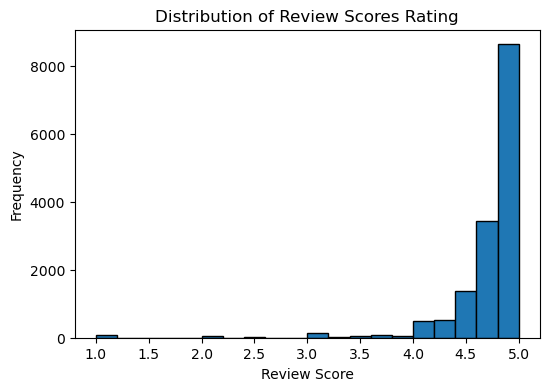

In [88]:
plt.figure(figsize=(6,4))
plt.hist(newyork["review_scores_rating"], bins=20, edgecolor='black')
plt.title("Distribution of Review Scores Rating")
plt.xlabel("Review Score")
plt.ylabel("Frequency")
plt.show()

In [89]:
rv_score_mean = newyork["review_scores_rating"].mean()
rv_score_mean

np.float64(4.731091542221924)

In [90]:
newyork.fillna({"review_scores_rating": rv_score_mean}, inplace = True)

In [91]:
newyork.isnull().sum()

host_response_rate                   0
host_acceptance_rate                 0
host_is_superhost                  308
host_total_listings_count         1042
neighbourhood_group_cleansed         0
room_type                            0
accommodates                         0
bathrooms                            7
bedrooms                            85
beds                                41
price                                0
minimum_nights                       0
maximum_nights                       0
has_availability                     0
availability_30                      0
availability_365                     0
number_of_reviews                    0
review_scores_rating                 0
instant_bookable                     0
calculated_host_listings_count       0
log_price                            0
dtype: int64

In [92]:
newyork.head()

,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,neighbourhood_group_cleansed,room_type,accommodates,bathrooms,bedrooms,beds,...,minimum_nights,maximum_nights,has_availability,availability_30,availability_365,number_of_reviews,review_scores_rating,instant_bookable,calculated_host_listings_count,log_price
0,1.000000,0.54,t,3.0,Queens,Private room,1,1.0,1.0,1.0,...,30,365,t,16,77,16,4.81,f,3,4.204693
4,0.900000,0.69,t,16.0,Manhattan,Private room,1,2.0,1.0,1.0,...,30,900,t,26,168,20,4.95,f,8,4.343805
5,0.750000,1.00,t,2.0,Queens,Entire home/apt,6,1.0,2.0,3.0,...,30,365,t,29,364,93,4.14,f,2,4.584967
7,0.891377,0.60,t,1.0,Brooklyn,Private room,1,1.0,2.0,1.0,...,30,35,t,0,187,26,4.92,f,1,4.110874
8,0.000000,0.00,f,9.0,Brooklyn,Entire home/apt,6,4.0,3.0,3.0,...,30,90,t,20,224,1,5.00,f,1,6.054439


In [93]:
#host is superhost >> mode substitute

In [94]:
newyork["host_is_superhost"].value_counts()

host_is_superhost
f    14372
t     6394
Name: count, dtype: int64

In [95]:
host_is_superhost_mode = newyork["host_is_superhost"].mode()[0]
host_is_superhost_mode

'f'

In [96]:
newyork.fillna({"host_is_superhost": host_is_superhost_mode}, inplace = True)

In [97]:
#host total listing count >>  mode substitute

In [98]:
host_total_listings_count_mode = newyork["host_total_listings_count"].mode()[0]
host_total_listings_count_mode

np.float64(1.0)

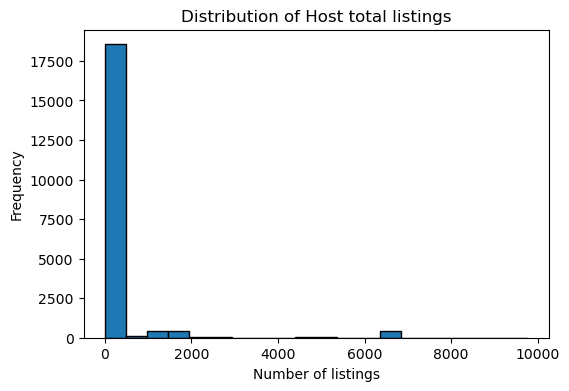

In [99]:
plt.figure(figsize=(6,4))
plt.hist(newyork["host_total_listings_count"], bins=20, edgecolor='black')
plt.title("Distribution of Host total listings")
plt.xlabel("Number of listings")
plt.ylabel("Frequency")
plt.show()

In [100]:
newyork.fillna({"host_total_listings_count": host_total_listings_count_mode}, inplace = True)

In [101]:
#bathrooms  >> mode substitute

In [102]:
newyork["bathrooms"].value_counts()

bathrooms
1.0     16455
2.0      2597
1.5       900
0.0       373
3.0       249
2.5       225
4.0        75
0.5        69
3.5        65
4.5        20
5.0        15
6.0         8
5.5         6
7.5         4
7.0         2
15.5        1
10.5        1
9.0         1
6.5         1
Name: count, dtype: int64

In [103]:
bathrooms_mode = newyork["bathrooms"].mode()[0]
bathrooms_mode

np.float64(1.0)

In [104]:
newyork.fillna({"bathrooms": bathrooms_mode}, inplace = True)

In [105]:
#bedroom  >> mode substitute

In [106]:
bedrooms_mode = newyork["bedrooms"].mode()[0]
bedrooms_mode

np.float64(1.0)

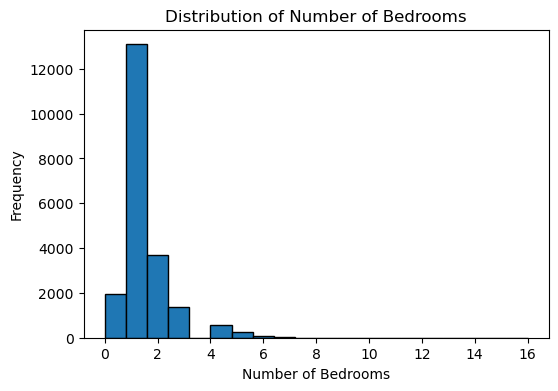

In [107]:
plt.figure(figsize=(6,4))
plt.hist(newyork["bedrooms"], bins=20, edgecolor='black')
plt.title("Distribution of Number of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Frequency")
plt.show()

In [108]:
newyork.fillna({"bedrooms": bedrooms_mode}, inplace = True)

In [109]:
newyork.isnull().sum()

host_response_rate                 0
host_acceptance_rate               0
host_is_superhost                  0
host_total_listings_count          0
neighbourhood_group_cleansed       0
room_type                          0
accommodates                       0
bathrooms                          0
bedrooms                           0
beds                              41
price                              0
minimum_nights                     0
maximum_nights                     0
has_availability                   0
availability_30                    0
availability_365                   0
number_of_reviews                  0
review_scores_rating               0
instant_bookable                   0
calculated_host_listings_count     0
log_price                          0
dtype: int64

In [110]:
#bed >>  mode substitute

In [111]:
newyork["beds"].value_counts()

beds
1.0     12269
2.0      4803
3.0      1762
4.0       844
0.0       755
5.0       305
6.0       143
7.0        69
8.0        42
9.0        13
10.0        8
12.0        5
11.0        4
13.0        4
19.0        2
16.0        2
40.0        1
17.0        1
21.0        1
Name: count, dtype: int64

In [112]:
beds_mode = newyork["beds"].mode()[0]
beds_mode

np.float64(1.0)

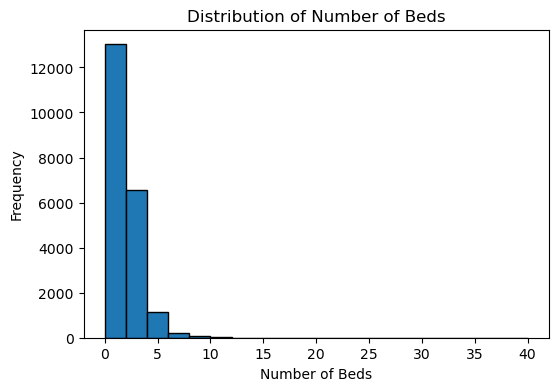

In [113]:
plt.figure(figsize=(6,4))
plt.hist(newyork["beds"], bins=20, edgecolor='black')
plt.title("Distribution of Number of Beds")
plt.xlabel("Number of Beds")
plt.ylabel("Frequency")
plt.show()

In [114]:
newyork.fillna({"beds": beds_mode}, inplace = True)

In [115]:
newyork.isnull().sum() #all missing values were handled

host_response_rate                0
host_acceptance_rate              0
host_is_superhost                 0
host_total_listings_count         0
neighbourhood_group_cleansed      0
room_type                         0
accommodates                      0
bathrooms                         0
bedrooms                          0
beds                              0
price                             0
minimum_nights                    0
maximum_nights                    0
has_availability                  0
availability_30                   0
availability_365                  0
number_of_reviews                 0
review_scores_rating              0
instant_bookable                  0
calculated_host_listings_count    0
log_price                         0
dtype: int64

In [116]:
newyork.shape

(21074, 21)

## 3. Data transformation

### *Dummy variables

In [117]:
newyork.head()

,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,neighbourhood_group_cleansed,room_type,accommodates,bathrooms,bedrooms,beds,...,minimum_nights,maximum_nights,has_availability,availability_30,availability_365,number_of_reviews,review_scores_rating,instant_bookable,calculated_host_listings_count,log_price
0,1.000000,0.54,t,3.0,Queens,Private room,1,1.0,1.0,1.0,...,30,365,t,16,77,16,4.81,f,3,4.204693
4,0.900000,0.69,t,16.0,Manhattan,Private room,1,2.0,1.0,1.0,...,30,900,t,26,168,20,4.95,f,8,4.343805
5,0.750000,1.00,t,2.0,Queens,Entire home/apt,6,1.0,2.0,3.0,...,30,365,t,29,364,93,4.14,f,2,4.584967
7,0.891377,0.60,t,1.0,Brooklyn,Private room,1,1.0,2.0,1.0,...,30,35,t,0,187,26,4.92,f,1,4.110874
8,0.000000,0.00,f,9.0,Brooklyn,Entire home/apt,6,4.0,3.0,3.0,...,30,90,t,20,224,1,5.00,f,1,6.054439


In [118]:
newyork["host_is_superhost"].value_counts()

host_is_superhost
f    14680
t     6394
Name: count, dtype: int64

In [119]:
newyork["neighbourhood_group_cleansed"].value_counts()

neighbourhood_group_cleansed
Manhattan        9323
Brooklyn         7366
Queens           3274
Bronx             807
Staten Island     304
Name: count, dtype: int64

In [120]:
newyork["room_type"].value_counts()

room_type
Entire home/apt    11857
Private room        8807
Hotel room           234
Shared room          176
Name: count, dtype: int64

In [121]:
newyork["instant_bookable"].value_counts()

instant_bookable
f    15713
t     5361
Name: count, dtype: int64

In [122]:
newyork2 = pd.get_dummies(newyork, columns=["host_is_superhost", "neighbourhood_group_cleansed", "room_type", "instant_bookable"],drop_first=True, dtype=int)

In [123]:
newyork2.drop(columns=["has_availability"],inplace=True) #drop availability column for now as it contains only active listings

In [124]:
newyork2.head()

,host_response_rate,host_acceptance_rate,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,...,log_price,host_is_superhost_t,neighbourhood_group_cleansed_Brooklyn,neighbourhood_group_cleansed_Manhattan,neighbourhood_group_cleansed_Queens,neighbourhood_group_cleansed_Staten Island,room_type_Hotel room,room_type_Private room,room_type_Shared room,instant_bookable_t
0,1.000000,0.54,3.0,1,1.0,1.0,1.0,66.0,30,365,...,4.204693,1,0,0,1,0,0,1,0,0
4,0.900000,0.69,16.0,1,2.0,1.0,1.0,76.0,30,900,...,4.343805,1,0,1,0,0,0,1,0,0
5,0.750000,1.00,2.0,6,1.0,2.0,3.0,97.0,30,365,...,4.584967,1,0,0,1,0,0,0,0,0
7,0.891377,0.60,1.0,1,1.0,2.0,1.0,60.0,30,35,...,4.110874,1,1,0,0,0,0,1,0,0
8,0.000000,0.00,9.0,6,4.0,3.0,3.0,425.0,30,90,...,6.054439,0,1,0,0,0,0,0,0,0


In [125]:
newyork2.shape

(21074, 25)

### *Multicollinearity check

In [126]:
newyork2.columns

Index(['host_response_rate', 'host_acceptance_rate',
       'host_total_listings_count', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'price', 'minimum_nights', 'maximum_nights', 'availability_30',
       'availability_365', 'number_of_reviews', 'review_scores_rating',
       'calculated_host_listings_count', 'log_price', 'host_is_superhost_t',
       'neighbourhood_group_cleansed_Brooklyn',
       'neighbourhood_group_cleansed_Manhattan',
       'neighbourhood_group_cleansed_Queens',
       'neighbourhood_group_cleansed_Staten Island', 'room_type_Hotel room',
       'room_type_Private room', 'room_type_Shared room',
       'instant_bookable_t'],
      dtype='object')

In [127]:
corr2 = newyork2.corr()
corr2

,host_response_rate,host_acceptance_rate,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,...,log_price,host_is_superhost_t,neighbourhood_group_cleansed_Brooklyn,neighbourhood_group_cleansed_Manhattan,neighbourhood_group_cleansed_Queens,neighbourhood_group_cleansed_Staten Island,room_type_Hotel room,room_type_Private room,room_type_Shared room,instant_bookable_t
host_response_rate,1.000000,0.355777,0.097236,-0.003660,-0.001228,0.020364,0.002524,0.049142,-0.093701,-0.009250,...,0.045353,0.233516,-0.008466,0.001024,0.012469,-0.014542,0.041357,0.039703,-0.001272,0.054879
host_acceptance_rate,0.355777,1.000000,-0.142750,0.090246,-0.016617,-0.086957,0.072159,0.069780,-0.182630,-0.015287,...,0.131574,0.276383,-0.039983,-0.014654,0.052777,0.006159,0.070206,0.010643,0.023628,0.299639
host_total_listings_count,0.097236,-0.142750,1.000000,-0.022738,-0.007482,0.038531,-0.113263,0.403491,-0.036473,0.044729,...,0.350315,-0.101161,-0.103729,0.178536,-0.079566,-0.028757,0.400771,-0.083427,-0.020572,0.024281
accommodates,-0.003660,0.090246,-0.022738,1.000000,0.386260,0.512689,0.688803,0.102402,-0.038629,0.055194,...,0.452364,0.004561,-0.033624,0.050060,-0.013700,0.001565,0.076693,-0.415262,-0.052524,0.085204
bathrooms,-0.001228,-0.016617,-0.007482,0.386260,1.000000,0.471434,0.385694,0.061347,0.023480,0.024022,...,0.180157,0.001012,0.086986,-0.049445,-0.035321,-0.001549,0.041892,-0.042083,0.025462,0.008306
bedrooms,0.020364,-0.086957,0.038531,0.512689,0.471434,1.000000,0.579438,0.025244,0.007636,-0.003229,...,0.151941,-0.027445,0.114638,-0.115312,0.013347,0.016127,0.011173,-0.076651,-0.017155,-0.042137
beds,0.002524,0.072159,-0.113263,0.688803,0.385694,0.579438,1.000000,-0.086546,-0.011717,0.002083,...,0.225821,0.051774,0.029723,-0.051986,0.028954,0.030547,-0.095799,-0.280305,-0.005265,-0.003822
price,0.049142,0.069780,0.403491,0.102402,0.061347,0.025244,-0.086546,1.000000,-0.112226,0.116694,...,0.610319,-0.066418,-0.071266,0.105842,-0.033334,-0.015047,0.832352,-0.079324,-0.011391,0.182051
minimum_nights,-0.093701,-0.182630,-0.036473,-0.038629,0.023480,0.007636,-0.011717,-0.112226,1.000000,0.103889,...,-0.141936,-0.088474,-0.006583,0.015843,-0.011952,0.001711,-0.109470,-0.117115,-0.011502,-0.135305
maximum_nights,-0.009250,-0.015287,0.044729,0.055194,0.024022,-0.003229,0.002083,0.116694,0.103889,1.000000,...,0.153225,-0.090401,-0.094294,0.115956,-0.038035,0.004797,0.105760,-0.111242,-0.019354,0.164839


In [128]:
import seaborn as sns

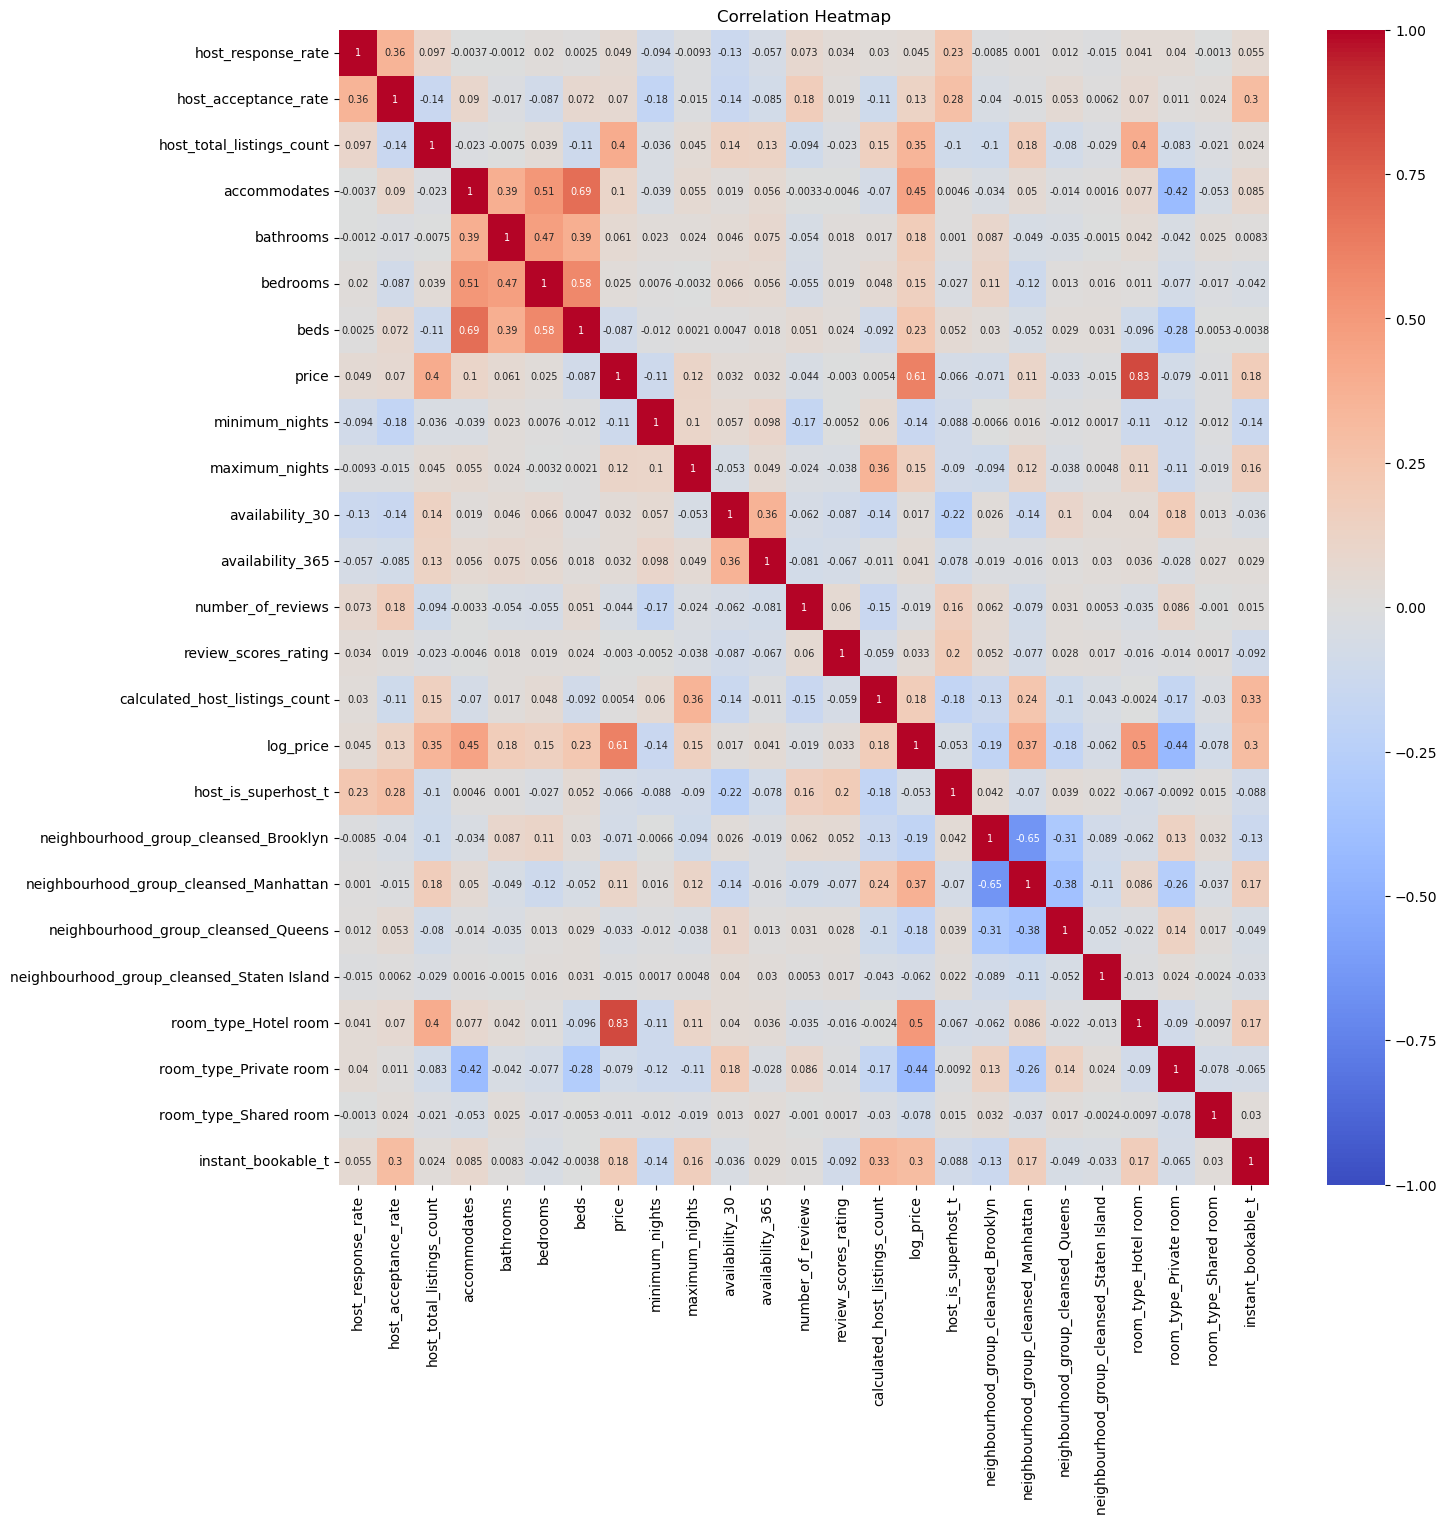

In [129]:
plt.figure(figsize=(15,15))
sns.heatmap(corr2, vmin=-1, vmax=1, center=0, annot=True, cmap="coolwarm", annot_kws={"fontsize":7})
plt.title("Correlation Heatmap")
plt.show()

## 4. Initial Model

In [130]:
import statsmodels.api as sm

In [131]:
newyork2.columns.get_loc("log_price")

15

In [132]:
y = newyork2.iloc[:,15]

In [133]:
newyork2.shape

(21074, 25)

In [134]:
newyork2.columns

Index(['host_response_rate', 'host_acceptance_rate',
       'host_total_listings_count', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'price', 'minimum_nights', 'maximum_nights', 'availability_30',
       'availability_365', 'number_of_reviews', 'review_scores_rating',
       'calculated_host_listings_count', 'log_price', 'host_is_superhost_t',
       'neighbourhood_group_cleansed_Brooklyn',
       'neighbourhood_group_cleansed_Manhattan',
       'neighbourhood_group_cleansed_Queens',
       'neighbourhood_group_cleansed_Staten Island', 'room_type_Hotel room',
       'room_type_Private room', 'room_type_Shared room',
       'instant_bookable_t'],
      dtype='object')

In [135]:
x = newyork2.iloc[:,[0,1,2,3,4,5,6,8,9,10,11,12,13,14,16,17,18,19,20,21,22,23,24]]

In [136]:
x.columns

Index(['host_response_rate', 'host_acceptance_rate',
       'host_total_listings_count', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'minimum_nights', 'maximum_nights', 'availability_30',
       'availability_365', 'number_of_reviews', 'review_scores_rating',
       'calculated_host_listings_count', 'host_is_superhost_t',
       'neighbourhood_group_cleansed_Brooklyn',
       'neighbourhood_group_cleansed_Manhattan',
       'neighbourhood_group_cleansed_Queens',
       'neighbourhood_group_cleansed_Staten Island', 'room_type_Hotel room',
       'room_type_Private room', 'room_type_Shared room',
       'instant_bookable_t'],
      dtype='object')

In [137]:
x.shape

(21074, 23)

In [138]:
x_c = sm.add_constant(x)

In [139]:
reg1 = sm.OLS(y,x_c).fit()
print(reg1.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.632
Model:                            OLS   Adj. R-squared:                  0.632
Method:                 Least Squares   F-statistic:                     1573.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:23:23   Log-Likelihood:                -19070.
No. Observations:               21074   AIC:                         3.819e+04
Df Residuals:                   21050   BIC:                         3.838e+04
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

### *Multicollinearity

In [140]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

In [141]:
x.values

array([[  1.  ,   0.54,   3.  , ...,   1.  ,   0.  ,   0.  ],
       [  0.9 ,   0.69,  16.  , ...,   1.  ,   0.  ,   0.  ],
       [  0.75,   1.  ,   2.  , ...,   0.  ,   0.  ,   0.  ],
       ...,
       [  1.  ,   0.92,  20.  , ...,   0.  ,   0.  ,   0.  ],
       [  0.49,   0.53, 261.  , ...,   0.  ,   0.  ,   0.  ],
       [  0.49,   0.53, 261.  , ...,   0.  ,   0.  ,   0.  ]],
      shape=(21074, 23))

In [142]:
x.shape[1]

23

In [143]:
vif_factors = [vif(x.values,i) for i in range(0, x.shape[1])]

In [144]:
pd.DataFrame({"Variable": x.columns, "VIF Factor": vif_factors})

,Variable,VIF Factor
0,host_response_rate,20.282075
1,host_acceptance_rate,13.243535
2,host_total_listings_count,1.475259
3,accommodates,7.599026
4,bathrooms,7.839102
5,bedrooms,5.619786
6,beds,6.725455
7,minimum_nights,2.549101
8,maximum_nights,2.794769
9,availability_30,2.727474


#### **Correction

In [145]:
x2 = newyork2.iloc[:,[1,2,3,4,5,6,8,9,10,11,12,13,14,16,17,18,19,20,21,22,23,24]] #drop host_response_rate due to higher VIF

In [146]:
x2_c = sm.add_constant(x2)

In [147]:
reg2 = sm.OLS(y,x2_c).fit()
print(reg2.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.632
Model:                            OLS   Adj. R-squared:                  0.632
Method:                 Least Squares   F-statistic:                     1644.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:23:24   Log-Likelihood:                -19072.
No. Observations:               21074   AIC:                         3.819e+04
Df Residuals:                   21051   BIC:                         3.837e+04
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [148]:
x2.values

array([[  0.54,   3.  ,   1.  , ...,   1.  ,   0.  ,   0.  ],
       [  0.69,  16.  ,   1.  , ...,   1.  ,   0.  ,   0.  ],
       [  1.  ,   2.  ,   6.  , ...,   0.  ,   0.  ,   0.  ],
       ...,
       [  0.92,  20.  ,   4.  , ...,   0.  ,   0.  ,   0.  ],
       [  0.53, 261.  ,   3.  , ...,   0.  ,   0.  ,   0.  ],
       [  0.53, 261.  ,   2.  , ...,   0.  ,   0.  ,   0.  ]],
      shape=(21074, 22))

In [149]:
x2.shape[1]

22

In [150]:
vif_factors_2 = [vif(x2.values,i) for i in range(0, x2.shape[1])]

In [151]:
pd.DataFrame({"Variable": x2.columns, "VIF Factor": vif_factors_2})

,Variable,VIF Factor
0,host_acceptance_rate,11.388758
1,host_total_listings_count,1.436007
2,accommodates,7.598866
3,bathrooms,7.838988
4,bedrooms,5.601182
5,beds,6.724712
6,minimum_nights,2.548928
7,maximum_nights,2.794723
8,availability_30,2.720772
9,availability_365,7.500415


In [152]:
#drop host_acceptance_rate and review_scores_rating due to high VIF

In [153]:
newyork2.columns.get_loc("review_scores_rating")

13

In [154]:
x3 = newyork2.iloc[:,[2,3,4,5,6,8,9,10,11,12,14,16,17,18,19,20,21,22,23,24]]

In [155]:
x3.head()

,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_30,availability_365,number_of_reviews,calculated_host_listings_count,host_is_superhost_t,neighbourhood_group_cleansed_Brooklyn,neighbourhood_group_cleansed_Manhattan,neighbourhood_group_cleansed_Queens,neighbourhood_group_cleansed_Staten Island,room_type_Hotel room,room_type_Private room,room_type_Shared room,instant_bookable_t
0,3.0,1,1.0,1.0,1.0,30,365,16,77,16,3,1,0,0,1,0,0,1,0,0
4,16.0,1,2.0,1.0,1.0,30,900,26,168,20,8,1,0,1,0,0,0,1,0,0
5,2.0,6,1.0,2.0,3.0,30,365,29,364,93,2,1,0,0,1,0,0,0,0,0
7,1.0,1,1.0,2.0,1.0,30,35,0,187,26,1,1,1,0,0,0,0,1,0,0
8,9.0,6,4.0,3.0,3.0,30,90,20,224,1,1,0,1,0,0,0,0,0,0,0


In [156]:
x3.shape

(21074, 20)

In [157]:
x3_c = sm.add_constant(x3)

In [158]:
reg3 = sm.OLS(y,x3_c).fit()
print(reg3.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.622
Model:                            OLS   Adj. R-squared:                  0.622
Method:                 Least Squares   F-statistic:                     1735.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:23:24   Log-Likelihood:                -19348.
No. Observations:               21074   AIC:                         3.874e+04
Df Residuals:                   21053   BIC:                         3.890e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [159]:
x3.values

array([[  3.,   1.,   1., ...,   1.,   0.,   0.],
       [ 16.,   1.,   2., ...,   1.,   0.,   0.],
       [  2.,   6.,   1., ...,   0.,   0.,   0.],
       ...,
       [ 20.,   4.,   1., ...,   0.,   0.,   0.],
       [261.,   3.,   1., ...,   0.,   0.,   0.],
       [261.,   2.,   1., ...,   0.,   0.,   0.]], shape=(21074, 20))

In [160]:
x3.shape[1]

20

In [161]:
vif_factors_3 = [vif(x3.values,i) for i in range(0, x3.shape[1])]

In [162]:
pd.DataFrame({"Variable": x3.columns, "VIF Factor": vif_factors_3})

,Variable,VIF Factor
0,host_total_listings_count,1.422595
1,accommodates,7.474328
2,bathrooms,7.642620
3,bedrooms,5.537251
4,beds,6.681954
5,minimum_nights,2.465517
6,maximum_nights,2.752715
7,availability_30,2.706916
8,availability_365,6.986950
9,number_of_reviews,1.297923


==> Multicollinearity issue was fixed

### *Heteroscedasticity

In [163]:
residual = reg3.resid

In [164]:
exog = reg3.model.exog

In [165]:
bp_test = sm.stats.het_breuschpagan(residual, exog)
bp_test

(np.float64(2145.183885641835),
 np.float64(0.0),
 np.float64(119.2957765334309),
 np.float64(0.0))

In [166]:
labels = ["Test Statistics", "p value", "f statistics", "f p-values"]

In [167]:
list(zip(labels, bp_test))

[('Test Statistics', np.float64(2145.183885641835)),
 ('p value', np.float64(0.0)),
 ('f statistics', np.float64(119.2957765334309)),
 ('f p-values', np.float64(0.0))]

As the p-value and f-value are both smaller than 0.05, there is a heteroscedasticity issue detected

#### **Correction

In [168]:
reg4 = sm.OLS(y,x3_c).fit(cov_type = "HC3")
print(reg4.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.622
Model:                            OLS   Adj. R-squared:                  0.622
Method:                 Least Squares   F-statistic:                     1337.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:23:25   Log-Likelihood:                -19348.
No. Observations:               21074   AIC:                         3.874e+04
Df Residuals:                   21053   BIC:                         3.890e+04
Df Model:                          20                                         
Covariance Type:                  HC3                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

### *Linearity

In [169]:
#compare fitted vs. actual

In [170]:
y_pred = reg4.predict() #model with constant term and heteroscedasticity issue fixed

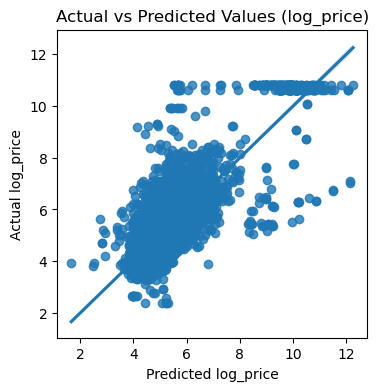

In [171]:
plt.figure(figsize=(4,4))
sns.regplot(x=y_pred, y=y)
plt.title("Actual vs Predicted Values (log_price)")
plt.xlabel("Predicted log_price")
plt.ylabel("Actual log_price")
plt.show()

In [172]:
#compare residual vs. fitted

In [173]:
residual = reg4.resid

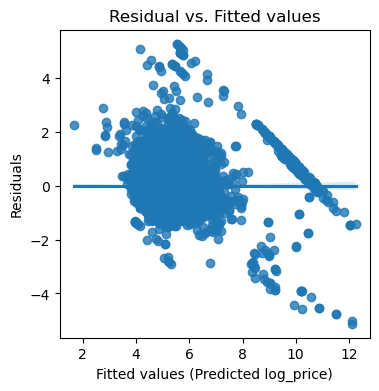

In [174]:
plt.figure(figsize=(4,4))
sns.regplot(x=y_pred, y=residual)
plt.title("Residual vs. Fitted values")
plt.xlabel("Fitted values (Predicted log_price)")
plt.ylabel("Residuals")
plt.show()

==> This suggests non-linearity and some model misspecification.

==> May need polynomial terms or interaction effects to better explain variance.

### *Normality of errors

In [175]:
# Q-Q Plot (residual normality)

<Figure size 200x200 with 0 Axes>

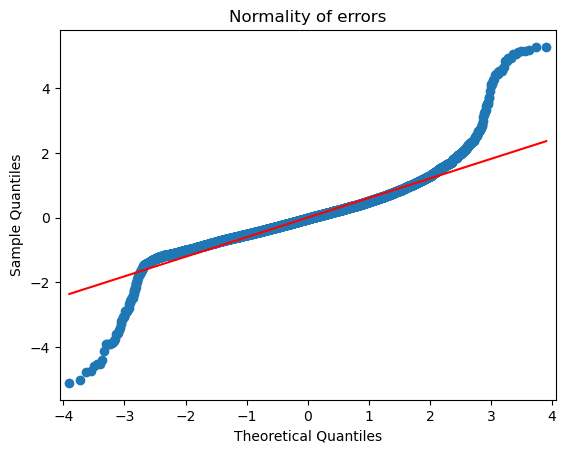

In [176]:
plt.figure(figsize = (2,2))
sm.qqplot(residual, line = "s")
plt.title("Normality of errors")
plt.show()

### *If we replace missing values in 'price' by median(price)

In [177]:
listing2 = listing.copy()

In [178]:
listing2.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,40824219,https://www.airbnb.com/rooms/40824219,20251001171547,2025-10-02,city scrape,Room close to Manhattan for FEMALE guests,This cozy spacious room includes a twin size b...,Sunnyside is a safe residental area. <br />The...,https://a0.muscache.com/pictures/hosting/Hosti...,317540555,...,4.88,4.94,4.69,NaN,f,3,0,3,0,0.23
1,40833186,https://www.airbnb.com/rooms/40833186,20251001171547,2025-10-02,previous scrape,Soho LES East village private room downtown,NaN,NaN,https://a0.muscache.com/pictures/1f093bbc-936c...,68718914,...,NaN,NaN,NaN,NaN,t,1,0,1,0,NaN
2,40837137,https://www.airbnb.com/rooms/40837137,20251001171547,2025-10-02,previous scrape,Sunset Park - Quiet and close to subway!,"Cozy, lovely bedroom with a comfortable full s...",the sunset park of Brooklyn,https://a0.muscache.com/pictures/01c4e91e-4012...,317770098,...,5.00,5.00,5.00,NaN,f,1,0,1,0,0.01
3,40838018,https://www.airbnb.com/rooms/40838018,20251001171547,2025-10-02,previous scrape,Cozy One Bedroom in Clinton Hill,This sunny one-bedroom apartment is located in...,Clinton Hill is one of the best neighborhoods ...,https://a0.muscache.com/pictures/9322d54a-6eb7...,17211451,...,5.00,5.00,5.00,NaN,t,1,1,0,0,0.01
4,40839416,https://www.airbnb.com/rooms/40839416,20251001171547,2025-10-02,city scrape,ðŸª´XL dojo ðŸŒ¾ shared green yogi palace apt ...,"New York City living at its best. A massive, c...",Live like the Ramones > The East Village is st...,https://a0.muscache.com/pictures/hosting/Hosti...,4765305,...,5.00,5.00,4.95,NaN,f,8,0,8,0,0.40


In [179]:
listing2.drop(columns=['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name',
                      'host_since', 'host_location', 'host_about',  'host_response_time', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count','host_verifications', 'host_has_profile_pic', 
                      'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'latitude', 'longitude', 
                      'property_type', 'bathrooms_text', 'amenities', 'minimum_minimum_nights', 'maximum_minimum_nights', 
                       'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated',
                      'availability_60', 'availability_90', 'calendar_last_scraped', 'number_of_reviews_ltm', 
                       'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d','estimated_revenue_l365d', 
                       'first_review', 'last_review', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin',
                       'review_scores_communication', 'review_scores_location', 'review_scores_value', 'license', 'calculated_host_listings_count_entire_homes',
                       'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'reviews_per_month'], inplace=True)   

In [180]:
listing2.columns #after cleaning redundant and useful data

Index(['host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_total_listings_count', 'neighbourhood_group_cleansed',
       'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price',
       'minimum_nights', 'maximum_nights', 'has_availability',
       'availability_30', 'availability_365', 'number_of_reviews',
       'review_scores_rating', 'instant_bookable',
       'calculated_host_listings_count'],
      dtype='object')

In [181]:
listing2.isnull().sum()

host_response_rate                15774
host_acceptance_rate              15595
host_is_superhost                   384
host_total_listings_count          1167
neighbourhood_group_cleansed          0
room_type                             0
accommodates                          0
bathrooms                         14411
bedrooms                           5949
beds                              14468
price                             14783
minimum_nights                        0
maximum_nights                        0
has_availability                   5665
availability_30                       0
availability_365                      0
number_of_reviews                     0
review_scores_rating              11188
instant_bookable                      0
calculated_host_listings_count        0
dtype: int64

In [182]:
# has availability

In [183]:
listing2.drop(columns=["has_availability"], inplace = True)

In [184]:
listing2.isnull().sum()

host_response_rate                15774
host_acceptance_rate              15595
host_is_superhost                   384
host_total_listings_count          1167
neighbourhood_group_cleansed          0
room_type                             0
accommodates                          0
bathrooms                         14411
bedrooms                           5949
beds                              14468
price                             14783
minimum_nights                        0
maximum_nights                        0
availability_30                       0
availability_365                      0
number_of_reviews                     0
review_scores_rating              11188
instant_bookable                      0
calculated_host_listings_count        0
dtype: int64

In [185]:
#price

In [186]:
Q1 = listing2["price"].quantile(0.25)
Q3 = listing2["price"].quantile(0.75)

In [187]:
IQR = Q3 - Q1

In [188]:
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

In [189]:
listing3 = listing2[(listing2["price"] > lower) & (listing2["price"] < upper)]

In [190]:
listing3["price"].describe() 

count    19801.000000
mean       178.923590
std        122.304786
min         10.000000
25%         85.000000
50%        145.000000
75%        240.000000
max        563.000000
Name: price, dtype: float64

In [191]:
price_med = listing3["price"].median()
price_med

145.0

In [192]:
listing2.fillna({"price": price_med}, inplace = True)

In [193]:
listing2["price"].describe()

count    36111.000000
mean       461.294647
std       3453.340728
min         10.000000
25%        132.000000
50%        145.000000
75%        180.000000
max      50104.000000
Name: price, dtype: float64

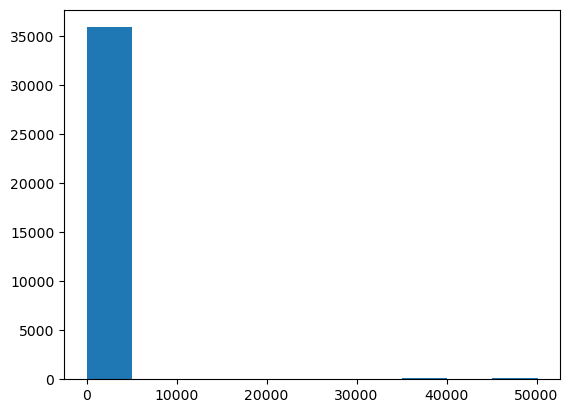

In [194]:
plt.hist(listing2["price"])
plt.show()

In [195]:
listing2["log_price"] = np.log(listing2["price"]+1)

In [196]:
listing2.columns

Index(['host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_total_listings_count', 'neighbourhood_group_cleansed',
       'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price',
       'minimum_nights', 'maximum_nights', 'availability_30',
       'availability_365', 'number_of_reviews', 'review_scores_rating',
       'instant_bookable', 'calculated_host_listings_count', 'log_price'],
      dtype='object')

In [197]:
listing2["log_price"]

0        4.204693
1        4.983607
2        4.983607
3        4.983607
4        4.343805
           ...   
36106    5.170484
36107    5.521461
36108    5.488938
36109    5.141664
36110    4.927254
Name: log_price, Length: 36111, dtype: float64

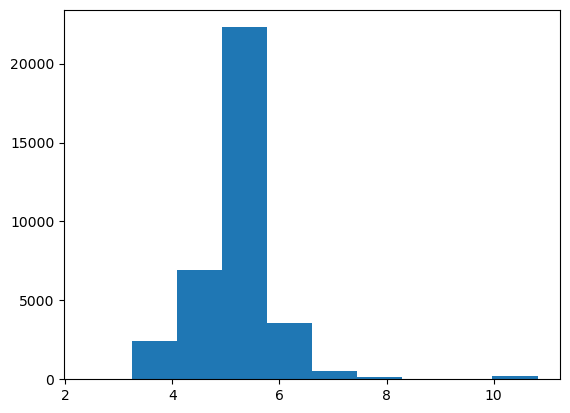

In [198]:
plt.hist(listing2["log_price"])
plt.show()

In [199]:
listing2.isnull().sum()

host_response_rate                15774
host_acceptance_rate              15595
host_is_superhost                   384
host_total_listings_count          1167
neighbourhood_group_cleansed          0
room_type                             0
accommodates                          0
bathrooms                         14411
bedrooms                           5949
beds                              14468
price                                 0
minimum_nights                        0
maximum_nights                        0
availability_30                       0
availability_365                      0
number_of_reviews                     0
review_scores_rating              11188
instant_bookable                      0
calculated_host_listings_count        0
log_price                             0
dtype: int64

In [200]:
response_rate_mean1 = listing2["host_response_rate"].mean()
response_rate_mean1

np.float64(0.8941131927029551)

In [201]:
listing2.fillna({"host_response_rate": response_rate_mean1}, inplace = True)

In [202]:
acceptance_rate_mean1 = listing2["host_acceptance_rate"].mean()
acceptance_rate_mean1

np.float64(0.7451213686878534)

In [203]:
listing2.fillna({"host_acceptance_rate": acceptance_rate_mean1}, inplace = True)

In [204]:
rv_score_mean1 = listing2["review_scores_rating"].mean()
rv_score_mean1

np.float64(4.722112506520082)

In [205]:
listing2.fillna({"review_scores_rating": rv_score_mean1}, inplace = True)

In [206]:
host_is_superhost_mode1 = listing2["host_is_superhost"].mode()[0]
host_is_superhost_mode1

'f'

In [207]:
listing2.fillna({"host_is_superhost": host_is_superhost_mode1}, inplace = True)

In [208]:
host_total_listings_count_mode1 = listing2["host_total_listings_count"].mode()[0]
host_total_listings_count_mode1

np.float64(1.0)

In [209]:
listing2.fillna({"host_total_listings_count": host_total_listings_count_mode1}, inplace = True)

In [210]:
bathrooms_mode1 = listing2["bathrooms"].mode()[0]
bathrooms_mode1

np.float64(1.0)

In [211]:
listing2.fillna({"bathrooms": bathrooms_mode1}, inplace = True)

In [212]:
bedrooms_mode1 = listing2["bedrooms"].mode()[0]
bedrooms_mode1

np.float64(1.0)

In [213]:
listing2.fillna({"bedrooms": bedrooms_mode1}, inplace = True)

In [214]:
beds_mode1 = listing2["beds"].mode()[0]
beds_mode1

np.float64(1.0)

In [215]:
listing2.fillna({"beds": beds_mode1}, inplace = True)

In [216]:
listing2.isnull().sum()

host_response_rate                0
host_acceptance_rate              0
host_is_superhost                 0
host_total_listings_count         0
neighbourhood_group_cleansed      0
room_type                         0
accommodates                      0
bathrooms                         0
bedrooms                          0
beds                              0
price                             0
minimum_nights                    0
maximum_nights                    0
availability_30                   0
availability_365                  0
number_of_reviews                 0
review_scores_rating              0
instant_bookable                  0
calculated_host_listings_count    0
log_price                         0
dtype: int64

In [217]:
listing4 = pd.get_dummies(listing2, columns=["host_is_superhost", "neighbourhood_group_cleansed", "room_type", "instant_bookable"],drop_first=True, dtype=int)

In [218]:
lt_corr = listing4.corr()
lt_corr

,host_response_rate,host_acceptance_rate,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,...,log_price,host_is_superhost_t,neighbourhood_group_cleansed_Brooklyn,neighbourhood_group_cleansed_Manhattan,neighbourhood_group_cleansed_Queens,neighbourhood_group_cleansed_Staten Island,room_type_Hotel room,room_type_Private room,room_type_Shared room,instant_bookable_t
host_response_rate,1.000000e+00,3.395439e-01,0.101765,-0.006880,-0.008860,0.015468,-0.005160,0.044053,-0.061235,2.246863e-07,...,0.038951,0.203339,-0.009617,-0.002566,0.021021,-0.011049,0.043914,0.041443,-0.002040,0.057419
host_acceptance_rate,3.395439e-01,1.000000e+00,-0.125371,0.089638,-0.012935,-0.081814,0.067107,0.064099,-0.129588,-1.792573e-07,...,0.117868,0.252925,-0.043237,0.010804,0.027120,0.006913,0.072081,0.004035,0.020403,0.279933
host_total_listings_count,1.017650e-01,-1.253713e-01,1.000000,0.005276,0.010425,0.048620,-0.070590,0.360323,-0.048987,-1.108418e-03,...,0.314090,-0.056855,-0.093488,0.141422,-0.051443,-0.020953,0.423703,-0.064926,-0.016166,0.064921
accommodates,-6.880123e-03,8.963805e-02,0.005276,1.000000,0.333216,0.520905,0.574694,0.091285,-0.033171,-4.886489e-03,...,0.382690,0.032953,-0.025307,0.048895,-0.027516,0.004686,0.073142,-0.423620,-0.047037,0.090998
bathrooms,-8.860433e-03,-1.293474e-02,0.010425,0.333216,1.000000,0.410555,0.424761,0.076281,-0.004135,-1.402852e-03,...,0.196820,0.068917,0.055132,-0.037836,-0.021875,0.009910,0.036540,-0.051030,0.026735,0.035486
bedrooms,1.546775e-02,-8.181390e-02,0.048620,0.520905,0.410555,1.000000,0.494745,0.025883,0.005711,-1.939786e-03,...,0.137102,-0.000436,0.102028,-0.098334,0.001361,0.017053,0.010586,-0.122190,-0.018321,-0.022833
beds,-5.159555e-03,6.710698e-02,-0.070590,0.574694,0.424761,0.494745,1.000000,-0.057747,-0.034911,-1.991631e-03,...,0.243765,0.139482,0.006796,-0.037851,0.029448,0.042235,-0.069199,-0.227699,0.003253,0.041388
price,4.405321e-02,6.409881e-02,0.360323,0.091285,0.076281,0.025883,-0.057747,1.000000,-0.075445,-4.797238e-04,...,0.611998,-0.034398,-0.056895,0.080021,-0.023834,-0.009752,0.678387,-0.066380,-0.007608,0.159152
minimum_nights,-6.123526e-02,-1.295880e-01,-0.048987,-0.033171,-0.004135,0.005711,-0.034911,-0.075445,1.000000,2.540472e-04,...,-0.095316,-0.084962,0.010227,-0.012788,0.003612,0.004490,-0.087613,-0.072541,0.001089,-0.113173
maximum_nights,2.246863e-07,-1.792573e-07,-0.001108,-0.004886,-0.001403,-0.001940,-0.001992,-0.000480,0.000254,1.000000e+00,...,-0.000622,-0.002632,-0.004006,0.005876,-0.002185,-0.000533,-0.000519,-0.004788,-0.000434,-0.002697


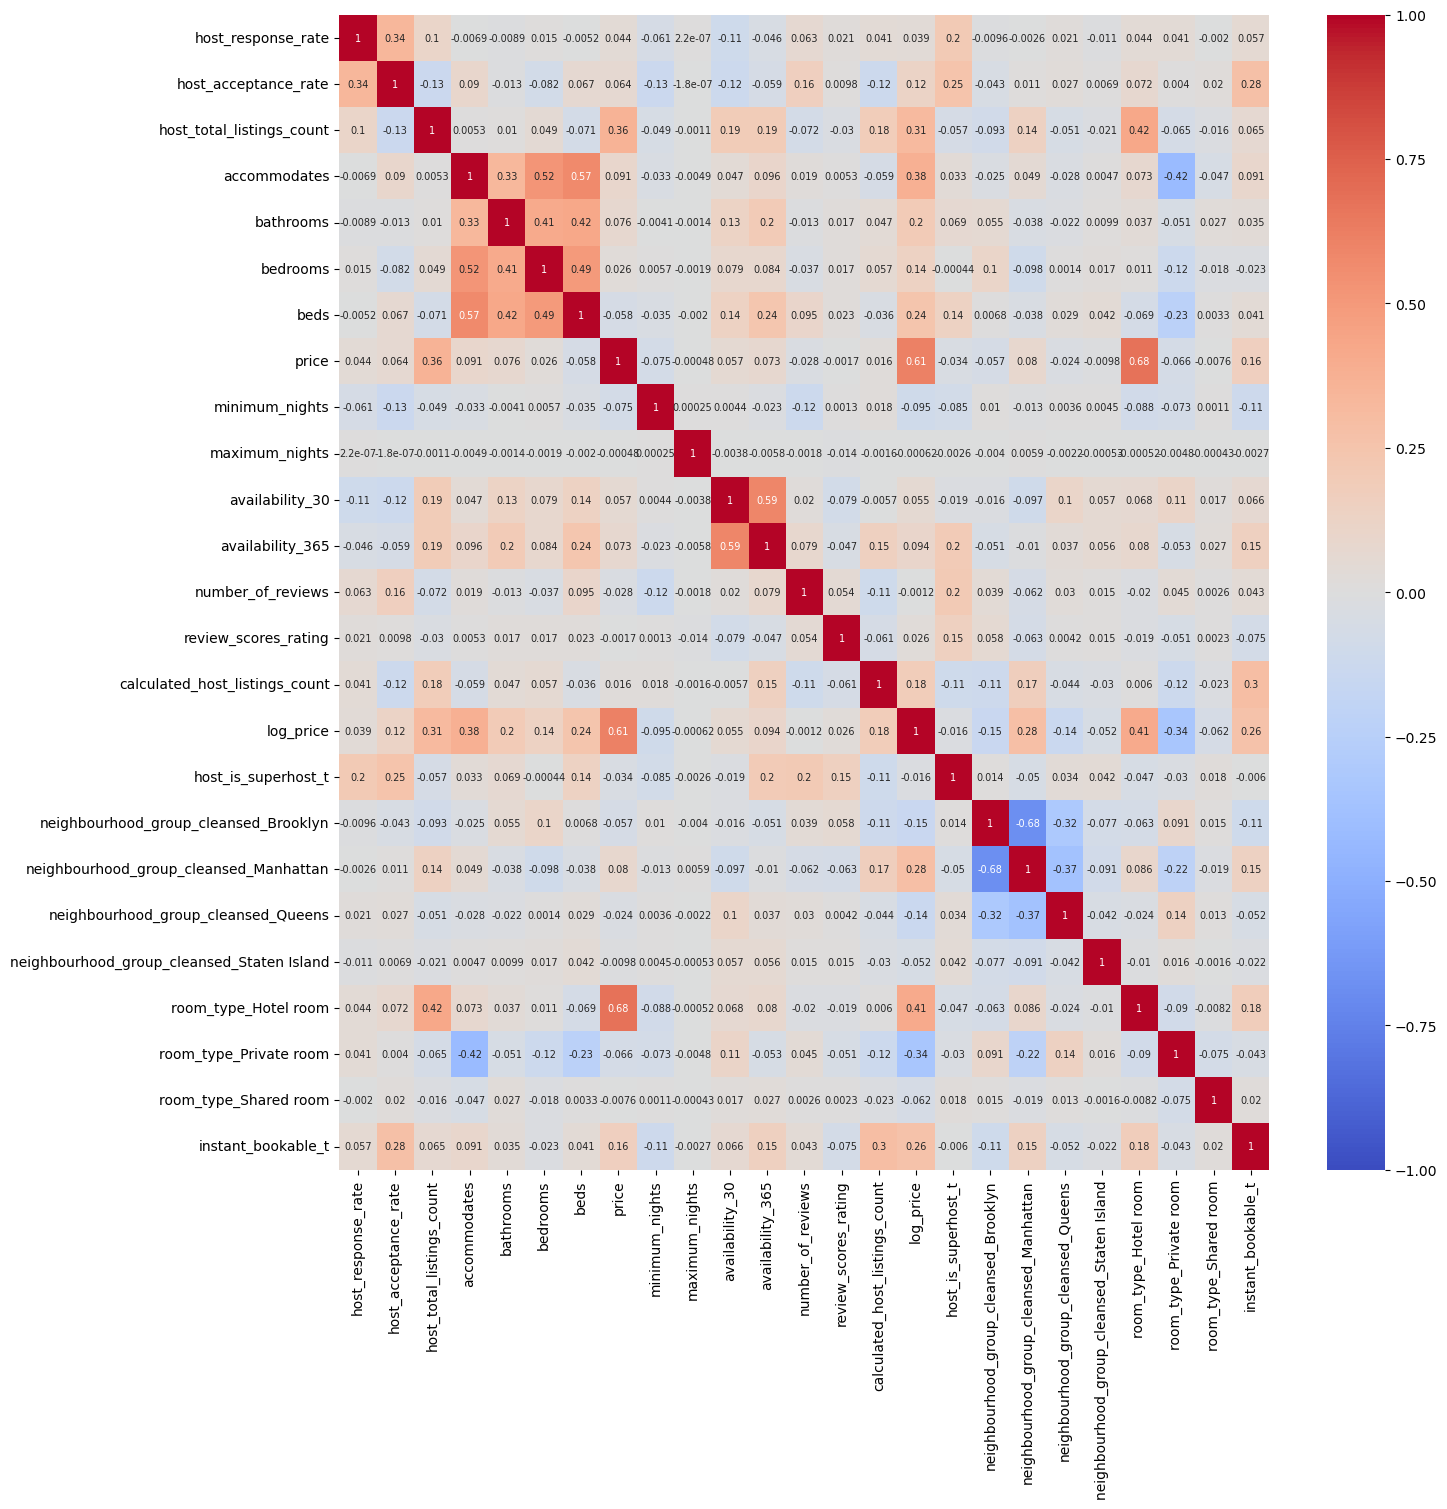

In [219]:
#Correlation heatmap
plt.figure(figsize=(15,15))
sns.heatmap(lt_corr, vmin=-1, vmax=1, center=0, annot=True, cmap="coolwarm", annot_kws={"fontsize":7})
plt.show()

In [220]:
#Regression

In [221]:
listing4.columns.get_loc("log_price")

15

In [222]:
y_lt4 = listing4.iloc[:,15]

In [223]:
listing4.shape

(36111, 25)

In [224]:
listing4.columns

Index(['host_response_rate', 'host_acceptance_rate',
       'host_total_listings_count', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'price', 'minimum_nights', 'maximum_nights', 'availability_30',
       'availability_365', 'number_of_reviews', 'review_scores_rating',
       'calculated_host_listings_count', 'log_price', 'host_is_superhost_t',
       'neighbourhood_group_cleansed_Brooklyn',
       'neighbourhood_group_cleansed_Manhattan',
       'neighbourhood_group_cleansed_Queens',
       'neighbourhood_group_cleansed_Staten Island', 'room_type_Hotel room',
       'room_type_Private room', 'room_type_Shared room',
       'instant_bookable_t'],
      dtype='object')

In [225]:
x_lt4 = listing4.iloc[:,[2,3,4,5,6,8,9,10,11,12,14,16,17,18,19,20,21,22,23,24]] 
#not include high VIF variables

In [226]:
x_lt4.columns

Index(['host_total_listings_count', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'minimum_nights', 'maximum_nights', 'availability_30',
       'availability_365', 'number_of_reviews',
       'calculated_host_listings_count', 'host_is_superhost_t',
       'neighbourhood_group_cleansed_Brooklyn',
       'neighbourhood_group_cleansed_Manhattan',
       'neighbourhood_group_cleansed_Queens',
       'neighbourhood_group_cleansed_Staten Island', 'room_type_Hotel room',
       'room_type_Private room', 'room_type_Shared room',
       'instant_bookable_t'],
      dtype='object')

In [227]:
x_lt4.shape

(36111, 20)

In [228]:
x_lt4_c = sm.add_constant(x_lt4)

In [229]:
reg_lt4_1 = sm.OLS(y_lt4,x_lt4_c).fit(cov_type="HC3")
print(reg_lt4_1.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.441
Model:                            OLS   Adj. R-squared:                  0.441
Method:                 Least Squares   F-statistic:                     857.2
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:23:28   Log-Likelihood:                -30777.
No. Observations:               36111   AIC:                         6.160e+04
Df Residuals:                   36090   BIC:                         6.177e+04
Df Model:                          20                                         
Covariance Type:                  HC3                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [230]:
#comparision
print(reg4.summary())
#reg model when removing missing values in price shows better results

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.622
Model:                            OLS   Adj. R-squared:                  0.622
Method:                 Least Squares   F-statistic:                     1337.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:23:28   Log-Likelihood:                -19348.
No. Observations:               21074   AIC:                         3.874e+04
Df Residuals:                   21053   BIC:                         3.890e+04
Df Model:                          20                                         
Covariance Type:                  HC3                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

### 5. Final model

In [231]:
print(reg4.summary()) 

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.622
Model:                            OLS   Adj. R-squared:                  0.622
Method:                 Least Squares   F-statistic:                     1337.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:23:28   Log-Likelihood:                -19348.
No. Observations:               21074   AIC:                         3.874e+04
Df Residuals:                   21053   BIC:                         3.890e+04
Df Model:                          20                                         
Covariance Type:                  HC3                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------